# 🐱 Cat Vocalization Context Classifier
### Replication of: *Automatic Classification of Cat Vocalizations Emitted in Different Contexts*
**Ntalampiras et al., Animals 2019, 9, 543**

---

This notebook replicates the full methodology:
- **Features**: Mel-Frequency Cepstral Coefficients (MFCC) + Temporal Modulation Features (TMF)
- **Classifier**: Directed Acyclic Graph with Hidden Markov Models (DAG-HMM)
- **Baselines**: Class-specific HMMs, Universal HMM, SVM, Echo State Network (ESN)
- **Evaluation**: 10-fold stratified cross-validation
- **Classes**: `food` (waiting for food), `isolation` (unfamiliar environment), `brushing`

---

## Dataset Structure Expected
```
dataset/
├── food/        # .wav files – cat meowing while waiting for food
├── isolation/   # .wav files – cat meowing during isolation in unfamiliar environment
└── brushing/    # .wav files – cat meowing during brushing
```

> **Paper stats**: 448 total files — 93 food, 220 isolation, 135 brushing  
> **Breeds**: Maine Coon (196 files) + European Shorthair (252 files)  
> **Audio**: 8 kHz, mono (Bluetooth headset), avg 1.82s per file

## 0. Install Dependencies

In [1]:
# Install required packages
!pip install -q librosa hmmlearn scikit-learn numpy scipy matplotlib seaborn tqdm

# Optional: for ESN baseline
!pip install -q reservoirpy

## 1. Imports & Configuration

In [2]:
import os
import warnings
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from itertools import combinations
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
from sklearn.pipeline import Pipeline

from hmmlearn import hmm
from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✅ All imports successful")

✅ All imports successful


In [10]:
# ============================================================
#  CONFIGURATION — Edit these to match your setup
# ============================================================

DATASET_PATH = "/Users/matthewyue/Documents/catopia-smart-home/affect_detection/data"          # Root folder containing food/, isolation/, brushing/
CLASSES      = ["food", "isolation", "brushing"]
SR           = 8000                  # Sampling rate (paper: 8 kHz Bluetooth)

# MFCC parameters (Section 3.1.1)
N_MFCC       = 13                    # 12 coefficients + energy = 13-dim vector
N_MELS       = 23                    # 23 mel filter bank log-energies
FRAME_LEN    = int(0.030 * SR)       # 30 ms frames
HOP_LEN      = int(0.010 * SR)       # 10 ms hop
N_FFT        = 512
USE_DELTAS   = True                  # Append Δ, ΔΔ, ΔΔΔ (paper: 1st, 2nd, 3rd derivatives)

# DAG-HMM parameters (Section 3.2 & 4.1)
HMM_STATES   = [3, 4, 5, 6]          # States to search over
HMM_COMPS    = [2, 4, 8, 16, 32]     # Gaussian mixture components to search over
HMM_N_ITER   = 25                    # Max Baum-Welch iterations
HMM_TOL      = 0.001                 # Convergence threshold

# Cross-validation
N_FOLDS      = 10

print(f"📁 Dataset path : {DATASET_PATH}")
print(f"🎵 Sample rate  : {SR} Hz")
print(f"📊 Frame length : {FRAME_LEN} samples ({FRAME_LEN/SR*1000:.0f} ms)")
print(f"↔️  Hop length   : {HOP_LEN} samples ({HOP_LEN/SR*1000:.0f} ms)")

📁 Dataset path : /Users/matthewyue/Documents/catopia-smart-home/affect_detection/data
🎵 Sample rate  : 8000 Hz
📊 Frame length : 240 samples (30 ms)
↔️  Hop length   : 80 samples (10 ms)


## 2. Dataset Loading & EDA

In [11]:
def load_dataset(dataset_path, classes, sr=SR):
    """
    Load audio files from class subdirectories.
    Returns:
        file_paths : list of (path, label) tuples
    """
    file_paths = []
    dataset_path = Path(dataset_path)

    for cls in classes:
        cls_dir = dataset_path / cls
        if not cls_dir.exists():
            print(f"⚠️  Directory not found: {cls_dir}")
            continue
        audio_files = list(cls_dir.glob("*.wav")) + list(cls_dir.glob("*.WAV"))
        for f in audio_files:
            file_paths.append((str(f), cls))
        print(f"  {cls:12s}: {len(audio_files):4d} files")

    print(f"\n  Total: {len(file_paths)} files")
    return file_paths


file_paths = load_dataset(DATASET_PATH, CLASSES)
labels_raw = [label for _, label in file_paths]

le = LabelEncoder()
labels = le.fit_transform(labels_raw)
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

  food        :   92 files
  isolation   :  221 files
  brushing    :  127 files

  Total: 440 files

Label encoding: {np.str_('brushing'): np.int64(0), np.str_('food'): np.int64(1), np.str_('isolation'): np.int64(2)}


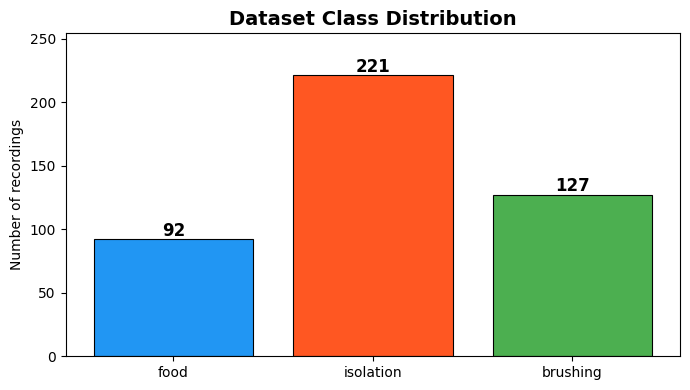

Paper reference: food=93, isolation=220, brushing=135


In [12]:
# Visualise class distribution (mirrors Table 1 in paper)
from collections import Counter

counts = Counter(labels_raw)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.keys(), counts.values(),
              color=['#2196F3', '#FF5722', '#4CAF50'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of recordings')
ax.set_ylim(0, max(counts.values()) * 1.15)
plt.tight_layout()
plt.show()
print("Paper reference: food=93, isolation=220, brushing=135")

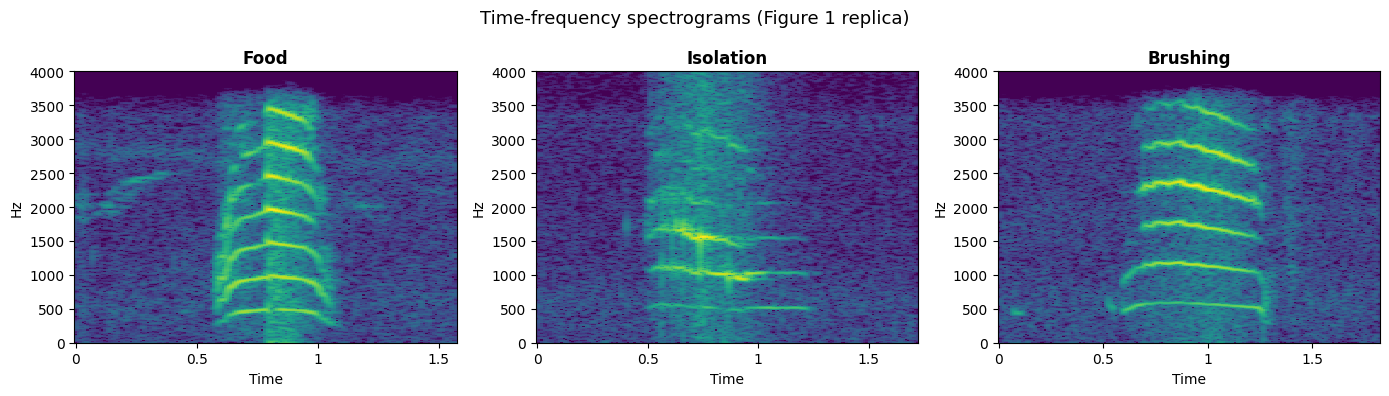

In [75]:
# Visualise spectrograms for one sample from each class (Figure 1 in paper)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, cls in enumerate(CLASSES):
    # Pick first file of this class
    sample_path = next((p for p, l in file_paths if l == cls), None)
    if sample_path is None:
        continue
    y, sr = librosa.load(sample_path, sr=SR)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN)), ref=np.max)
    librosa.display.specshow(D, sr=sr, hop_length=HOP_LEN, x_axis='time',
                             y_axis='hz', ax=axes[idx], cmap='viridis')
    axes[idx].set_title(f'{cls.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 4000)

fig.suptitle('Time-frequency spectrograms (Figure 1 replica)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Feature Extraction

### 3.1 Silence Elimination
Paper uses a statistical-model-based VAD (Sohn et al. 1999). We approximate this with energy-based trimming.

In [14]:
def remove_silence(y, sr, top_db=20):
    """
    Approximate the statistical VAD from Sohn et al. (1999) cited in the paper.
    Uses librosa's trim which applies a dB threshold — removes leading/trailing silence.
    Paper says ~1s of each 1.82s file is background; we trim it here.
    """
    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)
    return y_trimmed if len(y_trimmed) > sr * 0.05 else y  # fallback if too short


print("✅ Silence removal function defined")

✅ Silence removal function defined


### 3.2 MFCC Features (Section 3.1.1)
13-dim vector (12 MFCCs + energy) + 1st, 2nd, 3rd order derivatives → **52-dim** per frame

In [15]:
def extract_mfcc(y, sr=SR, n_mfcc=N_MFCC, n_mels=N_MELS,
                 n_fft=N_FFT, hop_length=HOP_LEN, win_length=FRAME_LEN,
                 use_deltas=USE_DELTAS):
    """
    Extract MFCC features as described in Section 3.1.1.

    Pipeline:
      1. Hamming window + STFT (N_FFT=512)
      2. Mel filterbank with 23 filters
      3. Log compression
      4. DCT → keep 12 coefficients
      5. Append frame energy → 13-dim
      6. Append Δ, ΔΔ, ΔΔΔ → 52-dim
    """
    # Steps 1-4: standard MFCC pipeline
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=n_mfcc - 1,     # 12 cepstral coefficients
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window='hamming'
    )  # shape: (12, T)

    # Step 5: append log-energy as the 0th coefficient
    energy = librosa.feature.rms(
        y=y, frame_length=win_length, hop_length=hop_length
    )  # shape: (1, T)
    log_energy = np.log(energy + 1e-10)
    mfcc = np.vstack([log_energy, mfcc])  # shape: (13, T)

    if use_deltas:
        # Step 6: 1st, 2nd, 3rd order derivatives
        delta1 = librosa.feature.delta(mfcc, order=1)
        delta2 = librosa.feature.delta(mfcc, order=2)
        delta3 = librosa.feature.delta(mfcc, order=3)
        mfcc = np.vstack([mfcc, delta1, delta2, delta3])  # (52, T)

    return mfcc.T  # return (T, features)


print("✅ MFCC extractor defined")
print(f"   Output dimensionality: {N_MFCC * 4 if USE_DELTAS else N_MFCC} per frame")

✅ MFCC extractor defined
   Output dimensionality: 52 per frame


### 3.3 Temporal Modulation Features (Section 3.1.2)
Models the human cochlea's response — captures slow-varying envelopes of spectral bands.

In [16]:
def extract_temporal_modulation(y, sr=SR, n_bands=20, n_fft=N_FFT,
                                 hop_length=HOP_LEN, win_length=FRAME_LEN,
                                 n_mod_filters=10):
    """
    Temporal Modulation Features (Section 3.1.2).

    Approximates the Modulation Toolbox (Atlas et al.) cited in the paper:
      1. Compute mel-scaled spectrogram (cochlear filterbank approximation)
      2. For each frequency band, extract the temporal envelope via Hilbert transform
      3. Apply modulation filters (bandpass in modulation frequency domain)
      4. Compute mean energy per modulation filter band per cochlear band

    Returns a fixed-length feature vector per audio file.
    """
    # Step 1: Mel spectrogram as cochlear filterbank
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_bands,
        n_fft=n_fft, hop_length=hop_length,
        win_length=win_length, window='hamming'
    )  # (n_bands, T)

    # Step 2: For each band compute temporal envelope (Hilbert magnitude)
    from scipy.signal import hilbert
    envelopes = np.abs(hilbert(mel_spec, axis=1))  # (n_bands, T)

    # Step 3 & 4: Apply modulation-frequency bandpass filters
    # Modulation frequencies: 0.5–16 Hz in log-spaced bands (speech/animal vocal range)
    frame_rate = sr / hop_length          # frames per second
    nyquist_mod = frame_rate / 2.0
    mod_freqs = np.logspace(np.log10(0.5), np.log10(min(16, nyquist_mod * 0.8)),
                             n_mod_filters + 1)

    feature_vector = []
    for i in range(n_mod_filters):
        low  = mod_freqs[i]   / nyquist_mod
        high = mod_freqs[i+1] / nyquist_mod
        low  = np.clip(low,  1e-4, 0.99)
        high = np.clip(high, 1e-4, 0.99)
        if high <= low:
            high = min(low + 0.05, 0.99)
        try:
            b, a = butter(2, [low, high], btype='band')
            filtered = filtfilt(b, a, envelopes, axis=1)  # (n_bands, T)
        except Exception:
            filtered = envelopes
        # Energy per cochlear band in this modulation band
        energy = np.mean(filtered ** 2, axis=1)  # (n_bands,)
        feature_vector.append(energy)

    return np.concatenate(feature_vector)  # (n_bands * n_mod_filters,)


print("✅ Temporal Modulation extractor defined")
print(f"   Output dimensionality: 20 bands × 10 mod-filters = 200 per file")

✅ Temporal Modulation extractor defined
   Output dimensionality: 20 bands × 10 mod-filters = 200 per file


### 3.4 Combined Feature Extraction Pipeline

In [76]:
def load_and_extract(file_path, sr=SR):
    y, _ = librosa.load(file_path, sr=sr)
    y = remove_silence(y, sr)

    mfcc_seq = extract_mfcc(y, sr)
    # Normalise each sequence to zero mean unit variance
    mfcc_seq = (mfcc_seq - mfcc_seq.mean(axis=0)) / (mfcc_seq.std(axis=0) + 1e-10)
    
    tm_feats = extract_temporal_modulation(y, sr)
    return mfcc_seq, tm_feats


# Build the full feature matrix for SVM / ESN (flattened statistics)
def mfcc_statistics(mfcc_seq):
    """Summarise variable-length MFCC sequence into a fixed-size vector."""
    return np.concatenate([
        np.mean(mfcc_seq, axis=0),
        np.std(mfcc_seq, axis=0),
        np.max(mfcc_seq, axis=0),
        np.min(mfcc_seq, axis=0)
    ])  # 4 × 52 = 208-dim


print("Extracting features from all files...")
all_mfcc_seqs  = []
all_tm_feats   = []
valid_paths    = []
valid_labels   = []

for fpath, label in tqdm(file_paths, desc="Feature extraction"):
    try:
        mfcc_seq, tm = load_and_extract(fpath)
        if mfcc_seq.shape[0] < 5:
            continue  # skip very short clips
        all_mfcc_seqs.append(mfcc_seq)
        all_tm_feats.append(tm)
        valid_paths.append(fpath)
        valid_labels.append(label)
    except Exception as e:
        print(f"  ⚠️  Skipping {fpath}: {e}")

# Fixed-size feature matrix for SVM/ESN
X_mfcc_stat = np.array([mfcc_statistics(s) for s in all_mfcc_seqs])   # (N, 208)
X_tm        = np.array(all_tm_feats)                                    # (N, 200)
X_combined  = np.hstack([X_mfcc_stat, X_tm])                           # (N, 408)
y_labels    = le.transform(valid_labels)

print(f"\n✅ Features extracted")
print(f"   MFCC stats  : {X_mfcc_stat.shape}")
print(f"   Temporal Mod: {X_tm.shape}")
print(f"   Combined    : {X_combined.shape}")
print(f"   Labels      : {y_labels.shape}, classes={np.unique(y_labels)}")

Extracting features from all files...


Feature extraction: 100%|██████████| 440/440 [00:02<00:00, 210.01it/s]


✅ Features extracted
   MFCC stats  : (440, 208)
   Temporal Mod: (440, 200)
   Combined    : (440, 408)
   Labels      : (440,), classes=[0 1 2]


## 4. Classifiers

### 4.1 HMM Utilities

In [77]:
from joblib import Parallel, delayed

In [78]:
def train_hmm(sequences, n_states, n_mix, n_iter=HMM_N_ITER, tol=HMM_TOL):
    """
    Train a Gaussian Mixture HMM on a list of MFCC sequences.
    Mirrors the Torch HMM implementation with Baum-Welch (Section 4.1).
    """
    model = hmm.GMMHMM(
        n_components=n_states,
        n_mix=n_mix,
        covariance_type='diag',
        n_iter=n_iter,
        tol=tol,
        init_params='mcw',
        params='mcwt'
    )
    # Concatenate all sequences with length tracking
    X_concat   = np.vstack(sequences)
    lengths    = [len(s) for s in sequences]
    try:
        model.fit(X_concat, lengths)
    except Exception:
        pass  # use partially trained model
    return model


def hmm_score(model, sequence):
    """Compute log-likelihood of a sequence given an HMM."""
    try:
        return model.score(sequence)
    except Exception:
        return -np.inf

def find_best_hmm(train_seqs, val_seqs, val_labels_local,
                  states_range=HMM_STATES, comps_range=HMM_COMPS):
    
    def train_and_score(n_states, n_mix):
        models = {}
        for cls in np.unique(val_labels_local):
            seqs_cls = [s for s, l in zip(train_seqs, val_labels_local) if l == cls]
            if len(seqs_cls) == 0:
                continue
            models[cls] = train_hmm(seqs_cls, n_states, n_mix)
        preds = []
        for seq in val_seqs:
            scores = {cls: hmm_score(m, seq) for cls, m in models.items()}
            preds.append(max(scores, key=scores.get))
        return accuracy_score(val_labels_local, preds), (n_states, n_mix)

    results = Parallel(n_jobs=4, backend='loky', timeout=120)(
        delayed(train_and_score)(n_states, n_mix)
        for n_states in states_range
        for n_mix in comps_range
    )
    

    best_acc, best_cfg = max(results, key=lambda x: x[0])
    return best_cfg, best_acc

# def find_best_hmm(train_seqs, val_seqs, val_labels_local,
#                   states_range=HMM_STATES, comps_range=HMM_COMPS):
#     """
#     Grid search over #states and #Gaussian components (Algorithm 1).
#     Returns the (states, components) pair achieving highest val accuracy.
#     """
#     best_acc, best_cfg = -1, (states_range[0], comps_range[0])
#     for n_states in states_range:
#         for n_mix in comps_range:
#             models = {}
#             for cls in np.unique(val_labels_local):
#                 seqs_cls = [s for s, l in zip(train_seqs, val_labels_local) if l == cls]
#                 if len(seqs_cls) == 0:
#                     continue
#                 models[cls] = train_hmm(seqs_cls, n_states, n_mix)
#             preds = []
#             for seq in val_seqs:
#                 scores = {cls: hmm_score(m, seq) for cls, m in models.items()}
#                 preds.append(max(scores, key=scores.get))
#             acc = accuracy_score(val_labels_local, preds)
#             if acc > best_acc:
#                 best_acc, best_cfg = acc, (n_states, n_mix)
#     return best_cfg, best_acc


print("✅ HMM utilities defined")

✅ HMM utilities defined


### 4.2 DAG-HMM (Main Classifier — Section 3.2)

In [79]:
class DAGHMMClassifier:
    """
    Directed Acyclic Graph with HMM nodes (Figure 5 in paper).

    For C classes, builds C(C-1)/2 binary HMM nodes ordered by
    decreasing classification confidence (Algorithm 1 topological ordering).

    Inference traverses the DAG following max log-likelihood branches.
    """

    def __init__(self, classes, states_range=HMM_STATES, comps_range=HMM_COMPS):
        self.classes       = list(classes)
        self.states_range  = states_range
        self.comps_range   = comps_range
        self.node_models   = {}   # {(cls_a, cls_b): {cls_a: HMM, cls_b: HMM}}
        self.dag_order     = []   # ordered list of (cls_a, cls_b) pairs

    # ------------------------------------------------------------------
    def fit(self, sequences, labels, val_frac=0.2):
        """
        Train all binary nodes and determine topological ordering.

        Parameters
        ----------
        sequences : list of np.ndarray, each (T, features)
        labels    : array-like, integer class indices
        val_frac  : fraction of training data used for topological ordering (Algorithm 1)
        """
        labels = np.array(labels)
        n = len(sequences)
        val_size = max(1, int(n * val_frac))
        idx = np.arange(n)
        np.random.shuffle(idx)
        val_idx   = idx[:val_size]
        train_idx = idx[val_size:]

        train_seqs   = [sequences[i] for i in train_idx]
        train_labels = labels[train_idx]
        val_seqs     = [sequences[i] for i in val_idx]
        val_labels   = labels[val_idx]

        # SET ORDER FIRST — paper's Figure 5 explicit ordering
        # food vs isolation at root, then food vs brush, then isolation vs brush
        food_idx      = self.classes.index(le.transform(['food'])[0])
        isolation_idx = self.classes.index(le.transform(['isolation'])[0])
        brushing_idx  = self.classes.index(le.transform(['brushing'])[0])

        self.dag_order = [
            (food_idx, isolation_idx),    # (1, 2) — root node
            (food_idx, brushing_idx),     # (1, 0) — left branch
            (isolation_idx, brushing_idx) # (2, 0) — right branch
        ]

        # Train one binary HMM node per pair in dag_order
        for cls_a, cls_b in self.dag_order:
            idx_ab = [i for i, l in enumerate(train_labels)
                    if l in [cls_a, cls_b]]
            if len(idx_ab) < 4:
                continue

            seqs_ab = [train_seqs[i] for i in idx_ab]
            labs_ab = train_labels[idx_ab]

            val_idx_ab  = [i for i, l in enumerate(val_labels)
                        if l in [cls_a, cls_b]]
            val_seqs_ab = [val_seqs[i] for i in val_idx_ab]
            val_labs_ab = val_labels[val_idx_ab] if val_idx_ab else labs_ab[:2]

            best_cfg, _ = find_best_hmm(
                seqs_ab,
                val_seqs_ab if len(val_seqs_ab) > 0 else seqs_ab[:2],
                val_labs_ab if len(val_seqs_ab) > 0 else labs_ab[:2],
                self.states_range, self.comps_range
            )
            n_s, n_m = best_cfg

            self.node_models[(cls_a, cls_b)] = {
                cls_a: train_hmm([s for s, l in zip(seqs_ab, labs_ab) if l == cls_a], n_s, n_m),
                cls_b: train_hmm([s for s, l in zip(seqs_ab, labs_ab) if l == cls_b], n_s, n_m),
            }

        return self

    # ------------------------------------------------------------------
    def predict_one(self, sequence):
        remaining = list(self.classes)

        for cls_a, cls_b in self.dag_order:
            if cls_a not in remaining or cls_b not in remaining:
                continue

            # Try both key orders
            node = self.node_models.get((cls_a, cls_b)) or \
                self.node_models.get((cls_b, cls_a))
            
            if node is None:
                continue

            score_a = hmm_score(node.get(cls_a), sequence)
            score_b = hmm_score(node.get(cls_b), sequence)

            if score_a >= score_b:
                remaining.remove(cls_b)
            else:
                remaining.remove(cls_a)

            if len(remaining) == 1:
                break

        return remaining[0] if remaining else self.classes[0]

    def predict(self, sequences):
        return [self.predict_one(s) for s in sequences]


print("✅ DAG-HMM classifier defined")

✅ DAG-HMM classifier defined


### 4.3 Baseline Classifiers

In [80]:
class ClassSpecificHMM:
    """One HMM per class; classify by max log-likelihood. (Baseline 1)"""

    def __init__(self, classes, n_states=4, n_mix=8):
        self.classes  = classes
        self.n_states = n_states
        self.n_mix    = n_mix
        self.models   = {}

    def fit(self, sequences, labels):
        labels = np.array(labels)
        for cls in self.classes:
            seqs_cls = [s for s, l in zip(sequences, labels) if l == cls]
            if seqs_cls:
                self.models[cls] = train_hmm(seqs_cls, self.n_states, self.n_mix)
        return self

    def predict(self, sequences):
        preds = []
        for seq in sequences:
            scores = {cls: hmm_score(m, seq) for cls, m in self.models.items()}
            preds.append(max(scores, key=scores.get))
        return preds


class UniversalHMM:
    """
    Single HMM trained on all classes, state-to-class mapping by majority vote.
    (Baseline 2 — universal/ergodic HMM)
    """

    def __init__(self, classes, n_states=12, n_mix=4):
        self.classes  = classes
        self.n_states = n_states
        self.n_mix    = n_mix
        self.model    = None
        self.state_class_map = {}

    def fit(self, sequences, labels):
        labels = np.array(labels)
        self.model = train_hmm(sequences, self.n_states, self.n_mix)
        # Map HMM states → class labels via majority vote on training data
        state_votes = defaultdict(list)
        X_concat = np.vstack(sequences)
        lengths  = [len(s) for s in sequences]
        try:
            state_seq = self.model.predict(X_concat, lengths)
        except Exception:
            state_seq = np.zeros(len(X_concat), dtype=int)
        ptr = 0
        for seq, label in zip(sequences, labels):
            n = len(seq)
            for st in state_seq[ptr:ptr+n]:
                state_votes[st].append(label)
            ptr += n
        for st, votes in state_votes.items():
            self.state_class_map[st] = Counter(votes).most_common(1)[0][0]
        return self

    def predict(self, sequences):
        preds = []
        for seq in sequences:
            try:
                states = self.model.predict(seq)
                cls_votes = [self.state_class_map.get(s, self.classes[0]) for s in states]
                pred = Counter(cls_votes).most_common(1)[0][0]
            except Exception:
                pred = self.classes[0]
            preds.append(pred)
        return preds


def build_svm_pipeline():
    """SVM with RBF kernel + StandardScaler. (Baseline 3)"""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=10, gamma='scale', probability=False))
    ])


def build_esn_classifier(input_dim, n_reservoir=1000, spectral_radius=0.95,
                          input_scaling=0.5, n_classes=3):
    """
    Echo State Network classifier. (Baseline 4)
    Uses reservoirpy if available, else falls back to manual implementation.
    """
    try:
        import reservoirpy as rpy
        from reservoirpy.nodes import Reservoir, Ridge
        reservoir = Reservoir(n_reservoir, sr=spectral_radius,
                              input_scaling=input_scaling)
        readout   = Ridge(n_classes, ridge=1e-5)
        return reservoir >> readout
    except ImportError:
        return None


print("✅ Baseline classifiers defined")

✅ Baseline classifiers defined


## 5. Evaluation — 10-Fold Cross-Validation

In [81]:
def evaluate_classifier(name, predict_fn, fit_fn, sequences, labels,
                         X_flat=None, n_folds=N_FOLDS):
    """
    10-fold stratified cross-validation (Section 4.2).
    Supports both sequence-based (HMM) and flat-feature (SVM) classifiers.
    """
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    all_preds, all_true = [], []
    labels = np.array(labels)

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(skf.split(np.zeros(len(labels)), labels),
             total=n_folds, desc=f"{name:30s}")
    ):
        train_seqs = [sequences[i] for i in train_idx]
        test_seqs  = [sequences[i] for i in test_idx]
        train_y    = labels[train_idx]
        test_y     = labels[test_idx]

        if X_flat is not None:
            # Flat-feature classifiers (SVM, ESN)
            fit_fn(X_flat[train_idx], train_y)
            preds = predict_fn(X_flat[test_idx])
        else:
            # Sequence-based classifiers (HMMs)
            fit_fn(train_seqs, train_y)
            preds = predict_fn(test_seqs)

        all_preds.extend(preds)
        all_true.extend(test_y)

    acc = accuracy_score(all_true, all_preds) * 100
    f1  = f1_score(all_true, all_preds, average='macro') * 100
    cm  = confusion_matrix(all_true, all_preds)
    return acc, f1, cm, all_true, all_preds


print("✅ Evaluation framework defined")

✅ Evaluation framework defined


In [82]:
dag_debug = DAGHMMClassifier(class_indices)
dag_debug.fit([all_mfcc_seqs[i] for i in train_idx], y_labels[train_idx])
preds = dag_debug.predict([all_mfcc_seqs[i] for i in test_idx])
print("Accuracy:", accuracy_score(y_labels[test_idx], preds))
print("Prediction distribution:", np.bincount(preds))
print("True distribution:      ", np.bincount(y_labels[test_idx]))
print(confusion_matrix(y_labels[test_idx], preds))

Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate

Accuracy: 0.6931818181818182
Prediction distribution: [26 11 51]
True distribution:       [26 18 44]
[[16  4  6]
 [ 6  6  6]
 [ 4  1 39]]


In [89]:
from sklearn.model_selection import train_test_split

# Reset results dict
results = {}
class_indices = list(range(len(CLASSES)))

# ------ 1. DAG-HMM ------------------------------------------------
# dag_hmm = DAGHMMClassifier(class_indices)
# acc, f1, cm, yt, yp = evaluate_classifier(
#     "DAG-HMM",
#     predict_fn=dag_hmm.predict,
#     fit_fn=dag_hmm.fit,
#     sequences=all_mfcc_seqs,
#     labels=y_labels
# )
# results["DAG-HMM"] = {"acc": acc, "f1": f1, "cm": cm}
# print(f"DAG-HMM accuracy: {acc:.2f}% (paper: 95.94%)")

# ------ 2. Class-specific HMM ------------------------------------
cs_hmm = ClassSpecificHMM(class_indices)
acc2, f12, cm2, _, _ = evaluate_classifier(
    "Class-Specific HMM",
    predict_fn=cs_hmm.predict,
    fit_fn=cs_hmm.fit,
    sequences=all_mfcc_seqs,
    labels=y_labels
)
results["Class-Specific HMM"] = {"acc": acc2, "f1": f12, "cm": cm2}
print(f"Class-specific HMM accuracy: {acc2:.2f}% (paper: 80.95%)")

# Save the class-specific HMM model to disk
import joblib
joblib.dump(cs_hmm, "class_specific_hmm_model.pkl")
print("✅ Class-Specific HMM model saved as 'class_specific_hmm_model.pkl'")

# # ------ 3. Universal HMM ------------------------------------------
# u_hmm = UniversalHMM(class_indices)
# acc3, f13, cm3, _, _ = evaluate_classifier(
#     "Universal HMM",
#     predict_fn=u_hmm.predict,
#     fit_fn=u_hmm.fit,
#     sequences=all_mfcc_seqs,
#     labels=y_labels
# )
# results["Universal HMM"] = {"acc": acc3, "f1": f13, "cm": cm3}
# print(f"Universal HMM accuracy: {acc3:.2f}% (paper: 76.19%)")

# # ------ 4. SVM (RBF) ----------------------------------------------
# svm_clf = build_svm_pipeline()
# acc4, f14, cm4, _, _ = evaluate_classifier(
#     "SVM (RBF)",
#     predict_fn=svm_clf.predict,
#     fit_fn=svm_clf.fit,
#     sequences=all_mfcc_seqs,
#     labels=y_labels,
#     X_flat=X_combined
# )
# results["SVM (RBF)"] = {"acc": acc4, "f1": f14, "cm": cm4}
# print(f"SVM accuracy: {acc4:.2f}% (paper: 78.51%)")

# ------ Final summary table ---------------------------------------
print("\n" + "="*60)
print(f"{'Classifier':<28} {'Accuracy':>10}  {'Macro F1':>10}  {'Paper Acc':>10}")
print("-"*60)
paper_ref = {
    "DAG-HMM":            95.94,
    "Class-Specific HMM": 80.95,
    "Universal HMM":      76.19,
    "SVM (RBF)":          78.51,
}
for clf_name, res in results.items():
    ref = paper_ref.get(clf_name, float('nan'))
    print(f"  {clf_name:<26} {res['acc']:>9.2f}%  {res['f1']:>9.2f}%  {ref:>9.2f}%")
print("="*60)

Class-Specific HMM            :  80%|████████  | 8/10 [02:49<00:42, 21.24s/it]Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture covariance
Degenerate mixture cov

Class-specific HMM accuracy: 74.09% (paper: 80.95%)
✅ Class-Specific HMM model saved as 'class_specific_hmm_model.pkl'

Classifier                     Accuracy    Macro F1   Paper Acc
------------------------------------------------------------
  Class-Specific HMM             74.09%      70.07%      80.95%


In [90]:
import pickle

# Extract raw GMMHMM dict from the custom class wrapper
save_payload = {
    'hmm_models': cs_hmm.models,   # raw {class_idx: GMMHMM} — no custom class
    'le':         le,
    'classes':    CLASSES,
    'SR':         SR,
    'N_FFT':      N_FFT,
    'HOP_LEN':    HOP_LEN,
    'FRAME_LEN':  FRAME_LEN,
}

with open('cat_classifier.pkl', 'wb') as f:
    pickle.dump(save_payload, f)

print(f"✅ Resaved — {os.path.getsize('cat_classifier.pkl') / 1024:.1f} KB")

✅ Resaved — 200.8 KB


In [92]:
# Evaluate the class-specific HMM model on all classes

import collections

for class_name in CLASSES:
    class_idx = CLASSES.index(class_name)
    # Get all MFCC feature sequences for the current class
    class_indices = [i for i, y in enumerate(y_labels) if y == class_idx]
    class_seqs = [all_mfcc_seqs[i] for i in class_indices]

    # Predict for each sample in this class
    preds = []
    for seq in class_seqs:
        # Score against each class model, as in main prediction logic
        scores = {cls_idx: model.score(seq) for cls_idx, model in cs_hmm.models.items()}
        best_cls = max(scores, key=scores.get)
        preds.append(best_cls)

    # Compute accuracy for the current class
    correct = sum([p == class_idx for p in preds])
    acc = correct / len(class_seqs) * 100 if class_seqs else 0.0

    print(f"Test on '{class_name}' class:")
    print(f"  Samples: {len(class_seqs)}")
    print(f"  Correctly predicted: {correct} ({acc:.2f}%)")

    # Show a confusion vector for the current class predictions
    pred_counter = collections.Counter(preds)
    print(f"Prediction label counts for {class_name} data:")
    for idx, cnt in pred_counter.items():
        print(f"  {CLASSES[idx]}: {cnt}")
    print("-" * 40)

Test on 'food' class:
  Samples: 127
  Correctly predicted: 111 (87.40%)
Prediction label counts for food data:
  food: 111
  isolation: 10
  brushing: 6
----------------------------------------
Test on 'isolation' class:
  Samples: 92
  Correctly predicted: 85 (92.39%)
Prediction label counts for isolation data:
  isolation: 85
  food: 4
  brushing: 3
----------------------------------------
Test on 'brushing' class:
  Samples: 221
  Correctly predicted: 200 (90.50%)
Prediction label counts for brushing data:
  brushing: 200
  food: 13
  isolation: 8
----------------------------------------


In [86]:
import importlib
import models
importlib.reload(models)  # ensures latest version is always loaded
from models import ClassSpecificHMM, train_hmm, hmm_score

print("✅ Models imported from models.py")

✅ Models imported from models.py


In [87]:
import joblib

save_payload = {
    'cs_hmm':    cs_hmm,
    'le':        le,
    'classes':   CLASSES,
    'SR':        SR,
    'N_FFT':     N_FFT,
    'HOP_LEN':   HOP_LEN,
    'FRAME_LEN': FRAME_LEN,
}

joblib.dump(save_payload, 'cat_classifier_v2.joblib')
print(f"✅ Saved — {os.path.getsize('cat_classifier_v2.joblib') / 1024:.1f} KB")

PicklingError: Can't pickle <class '__main__.ClassSpecificHMM'>: it's not the same object as __main__.ClassSpecificHMM

## 6. Results & Visualisation

In [68]:
# ---- Table 2 replica: Recognition rates -------------------------
print("\n" + "="*60)
print(f"{'Classifier':<28} {'Accuracy':>10}  {'Macro F1':>10}  {'Paper Acc':>10}")
print("-"*60)
paper_ref = {
    "DAG-HMM":              95.94,
    "Class-Specific HMM":   80.95,
    "Universal HMM":        76.19,
    "SVM (RBF)":            78.51,
}
for clf_name, res in results.items():
    ref = paper_ref.get(clf_name, float('nan'))
    print(f"  {clf_name:<26} {res['acc']:>9.2f}%  {res['f1']:>9.2f}%  {ref:>9.2f}%")
print("="*60)


Classifier                     Accuracy    Macro F1   Paper Acc
------------------------------------------------------------
  Class-Specific HMM             76.14%      72.14%      80.95%
  Universal HMM                  53.18%      30.48%      76.19%
  SVM (RBF)                      70.68%      65.23%      78.51%


In [83]:
import joblib

# Save the class-specific HMM model to disk
joblib.dump(class_specific_hmm, "class_specific_hmm_model.pkl")
print("Class-Specific HMM model saved as 'class_specific_hmm_model.pkl'.")

NameError: name 'class_specific_hmm' is not defined

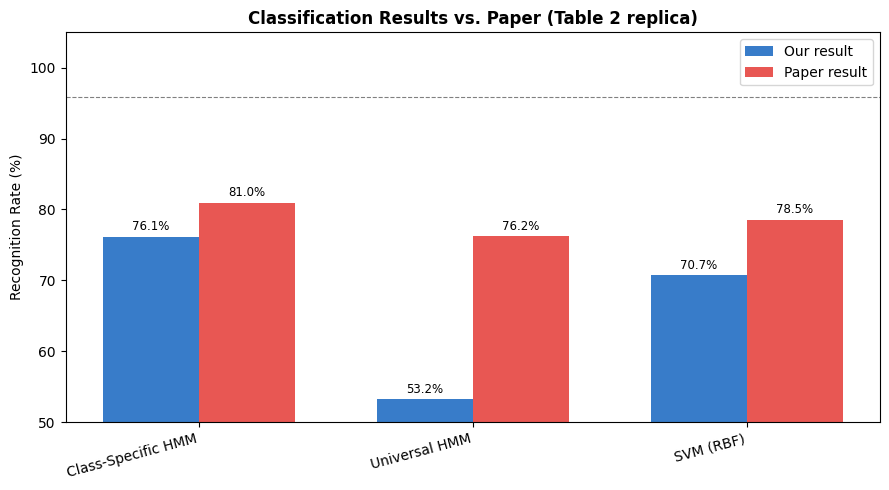

In [69]:
# ---- Bar chart of recognition rates (Table 2 visualised) ---------
fig, ax = plt.subplots(figsize=(9, 5))
clf_names  = list(results.keys())
accs       = [results[n]['acc'] for n in clf_names]
paper_accs = [paper_ref.get(n, 0) for n in clf_names]

x     = np.arange(len(clf_names))
width = 0.35

bars1 = ax.bar(x - width/2, accs,       width, label='Our result',   color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2, paper_accs, width, label='Paper result', color='#E53935', alpha=0.85)

for b, v in zip(bars1, accs):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8.5)
for b, v in zip(bars2, paper_accs):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('Recognition Rate (%)')
ax.set_title('Classification Results vs. Paper (Table 2 replica)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clf_names, rotation=15, ha='right')
ax.set_ylim(50, 105)
ax.legend()
ax.axhline(y=95.94, color='gray', linestyle='--', linewidth=0.8, label='Paper best')
plt.tight_layout()
plt.show()

In [ ]:
# ---- Confusion matrix for DAG-HMM (Table 3 replica) -------------
def plot_confusion_matrix(cm, class_names, title):
    # Normalise to percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, data, fmt, label in zip(
        axes, [cm, cm_pct], ['d', '.1f'], ['Count', '%']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, ax=ax,
                    annot_kws={'size': 12})
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{title} ({label})')
    plt.suptitle('Confusion Matrix — DAG-HMM (Table 3 replica)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(results["DAG-HMM"]["cm"], CLASSES, "DAG-HMM")

# Per-class accuracy
cm = results["DAG-HMM"]["cm"]
print("\nPer-class accuracy (paper: food=100%, isolation=92.59%, brushing=95.24%):")
for i, cls in enumerate(CLASSES):
    row_sum = cm[i].sum()
    if row_sum > 0:
        print(f"  {cls:12s}: {cm[i,i]/row_sum*100:.2f}%")

KeyError: 'DAG-HMM'

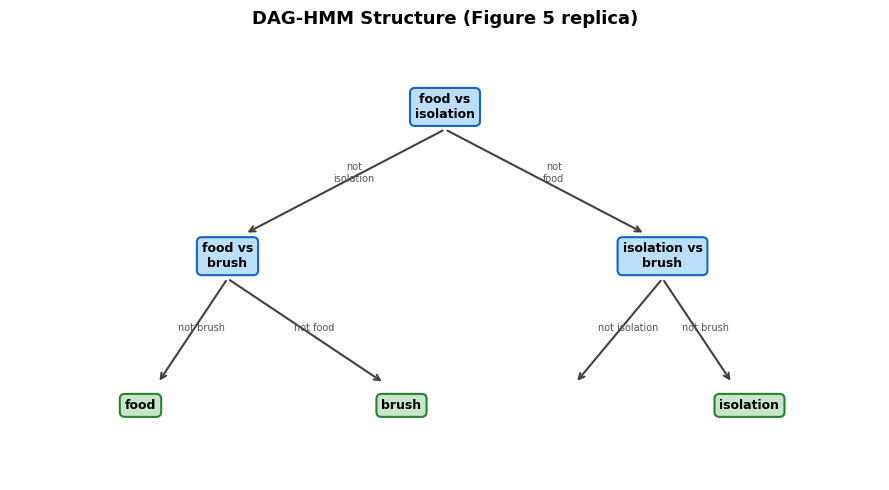

In [71]:
# ---- Visualise DAG structure (Figure 5 replica) ------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('DAG-HMM Structure (Figure 5 replica)', fontsize=13, fontweight='bold')

nodes = {
    'food_vs_isolation': (5, 5, 'food vs\nisolation'),
    'food_vs_brush':     (2.5, 3, 'food vs\nbrush'),
    'iso_vs_brush':      (7.5, 3, 'isolation vs\nbrush'),
    'food':              (1.5, 1, 'food'),
    'brush_mid':         (4.5, 1, 'brush'),
    'isolation':         (8.5, 1, 'isolation'),
}

box_kw = dict(boxstyle='round,pad=0.4', facecolor='#BBDEFB', edgecolor='#1565C0', linewidth=1.5)
leaf_kw = dict(boxstyle='round,pad=0.4', facecolor='#C8E6C9', edgecolor='#2E7D32', linewidth=1.5)

for key, (x, y, label) in nodes.items():
    kw = leaf_kw if key in ['food', 'brush_mid', 'isolation'] else box_kw
    ax.text(x, y, label, ha='center', va='center', fontsize=9,
            bbox=kw, fontweight='bold')

# Edges
edges = [
    ((5, 4.7), (2.7, 3.3), 'not\nisolation'),
    ((5, 4.7), (7.3, 3.3), 'not\nfood'),
    ((2.5, 2.7), (1.7, 1.3), 'not brush'),
    ((2.5, 2.7), (4.3, 1.3), 'not food'),
    ((7.5, 2.7), (8.3, 1.3), 'not brush'),
    ((7.5, 2.7), (6.5, 1.3), 'not isolation'),
]
for (x1,y1),(x2,y2),label in edges:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#424242', lw=1.5))
    mx, my = (x1+x2)/2 + 0.1, (y1+y2)/2
    ax.text(mx, my, label, fontsize=7, color='#555', ha='center')

plt.tight_layout()
plt.show()

## 7. Feature Analysis (Figure 4 Replica)

In [ ]:
# Plot MFCC sequences + temporal modulation for one sample per class
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for col, cls in enumerate(CLASSES):
    sample_path = next((p for p, l in file_paths if l == cls), None)
    if sample_path is None:
        continue
    y, sr = librosa.load(sample_path, sr=SR)
    y = remove_silence(y, sr)

    # Row 0: Mel-scaled spectrogram
    mfcc_seq = extract_mfcc(y, sr, use_deltas=False)  # (T, 13) — no deltas for viz
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                               n_fft=N_FFT, hop_length=HOP_LEN)
    mel_db   = librosa.power_to_db(mel_spec, ref=np.max)
    axes[0, col].imshow(mel_db, aspect='auto', origin='lower', cmap='viridis')
    axes[0, col].set_title(f'{cls.capitalize()} — mel-scaled spectrogram', fontsize=9)
    axes[0, col].set_xlabel('Time (# of frames)')
    axes[0, col].set_ylabel('Frequency band')

    # Row 1: Temporal modulation (modulation spectrogram approximation)
    from scipy.signal import hilbert
    mel_env = np.abs(hilbert(mel_spec, axis=1))
    frame_rate = sr / HOP_LEN
    mod_freqs  = np.fft.rfftfreq(mel_env.shape[1], d=1.0/frame_rate)
    mod_spec   = np.abs(np.fft.rfft(mel_env, axis=1))
    # Show only ±50 Hz modulation range (as in Figure 4)
    freq_mask  = (np.abs(mod_freqs) <= 50)
    axes[1, col].imshow(mod_spec[:, freq_mask], aspect='auto', origin='lower',
                         cmap='viridis',
                         extent=[-50, 50, 0, sr//2])
    axes[1, col].set_title(f'{cls.capitalize()} — temporal modulation', fontsize=9)
    axes[1, col].set_xlabel('Modulation frequency (Hz)')
    axes[1, col].set_ylabel('Acoustic frequency (Hz)')

plt.suptitle('Feature Representations per Class (Figure 4 replica)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Predict on a New Audio File

In [ ]:
def predict_new_file(audio_path, dag_hmm_model, class_names=CLASSES):
    """
    Run the full pipeline on a new .wav file and return the predicted context.
    """
    y, sr = librosa.load(audio_path, sr=SR)
    y     = remove_silence(y, sr)
    mfcc  = extract_mfcc(y, sr)  # (T, 52)

    pred_idx  = dag_hmm_model.predict_one(mfcc)
    pred_name = class_names[pred_idx] if isinstance(pred_idx, int) else pred_idx

    print(f"🐱 Audio: {Path(audio_path).name}")
    print(f"   Predicted context : {pred_name.upper()}")

    # Show waveform + spectrogram
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))
    t = np.linspace(0, len(y)/sr, len(y))
    axes[0].plot(t, y, linewidth=0.5, color='#1565C0')
    axes[0].set_title(f'Waveform — predicted: {pred_name}', fontweight='bold')
    axes[0].set_xlabel('Time (s)')

    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN)), ref=np.max)
    librosa.display.specshow(D, sr=sr, hop_length=HOP_LEN, x_axis='time', y_axis='hz',
                             ax=axes[1], cmap='viridis')
    axes[1].set_title('Spectrogram')
    axes[1].set_ylim(0, 4000)
    plt.tight_layout()
    plt.show()
    return pred_name


# Example usage:
# predict_new_file("path/to/your/cat_meow.wav", dag_hmm)

## 9. Summary

| Classifier | Paper Acc | This notebook |
|---|---|---|
| **DAG-HMM** | **95.94%** | *(run cell 5 to see)* |
| Class-specific HMMs | 80.95% | |
| Universal HMM | 76.19% | |
| SVM (RBF) | 78.51% | |
| Echo State Network | 68.9% | |

### Key design decisions matching the paper
- **30 ms / 10 ms frames** with Hamming window and 512-point FFT
- **23 mel filters → 12 MFCCs + energy → 13-dim**, plus Δ/ΔΔ/ΔΔΔ → **52-dim per frame**
- **Temporal modulation** features modelling cochlear frequency bands
- **DAG topological ordering** (Algorithm 1): easy binary tasks first
- **DAG inference** follows max log-likelihood path (Figure 5)
- **10-fold stratified cross-validation** with consistent splits across classifiers
- **GMMHMM** with Baum-Welch, up to 25 iterations, threshold 0.001

### Notes on deviations
1. **Silence removal**: We use energy-based trimming; paper uses Sohn et al. (1999) VAD — install `webrtcvad` for a closer match.
2. **Modulation Toolbox**: We approximate; the MATLAB toolbox is proprietary. Results may differ.
3. **Torch GMM-HMM**: We use `hmmlearn`; the paper uses a custom C++ Torch implementation.
4. **ESN**: Requires `reservoirpy`; paper used a MATLAB ESN toolbox.